ESERCIZIO

Modifica il loop di addestramento visto in lezione per applicare il label smoothing solo alle immagini reali.
Successivamente, cambia la dimensione del vettore latente da 100 a 10
Come influisce questa restrizione sulla qualità delle cifre generate?
Suggerimento: osserva se il modello inizia a produrre numeri meno vari o più sfuocati.

Avvio addestramento su cpu con Latent Dim: 10
------------------------------------------------------------
Epoca [1/15] | Loss_D: 1.182 | Loss_G: 1.172 | D(x): 0.60 | D(G(z)): 0.30
Epoca [2/15] | Loss_D: 1.243 | Loss_G: 1.139 | D(x): 0.52 | D(G(z)): 0.31
Epoca [3/15] | Loss_D: 1.287 | Loss_G: 1.043 | D(x): 0.50 | D(G(z)): 0.34
Epoca [4/15] | Loss_D: 1.296 | Loss_G: 1.019 | D(x): 0.49 | D(G(z)): 0.35
Epoca [5/15] | Loss_D: 1.299 | Loss_G: 1.004 | D(x): 0.49 | D(G(z)): 0.36
Epoca [6/15] | Loss_D: 1.308 | Loss_G: 0.982 | D(x): 0.49 | D(G(z)): 0.37
Epoca [7/15] | Loss_D: 1.315 | Loss_G: 0.961 | D(x): 0.48 | D(G(z)): 0.37
Epoca [8/15] | Loss_D: 1.320 | Loss_G: 0.951 | D(x): 0.48 | D(G(z)): 0.38
Epoca [9/15] | Loss_D: 1.328 | Loss_G: 0.933 | D(x): 0.48 | D(G(z)): 0.39
Epoca [10/15] | Loss_D: 1.332 | Loss_G: 0.923 | D(x): 0.48 | D(G(z)): 0.39
Epoca [11/15] | Loss_D: 1.336 | Loss_G: 0.910 | D(x): 0.47 | D(G(z)): 0.39
Epoca [12/15] | Loss_D: 1.339 | Loss_G: 0.903 | D(x): 0.47 | D(G(z)): 0.40
Ep

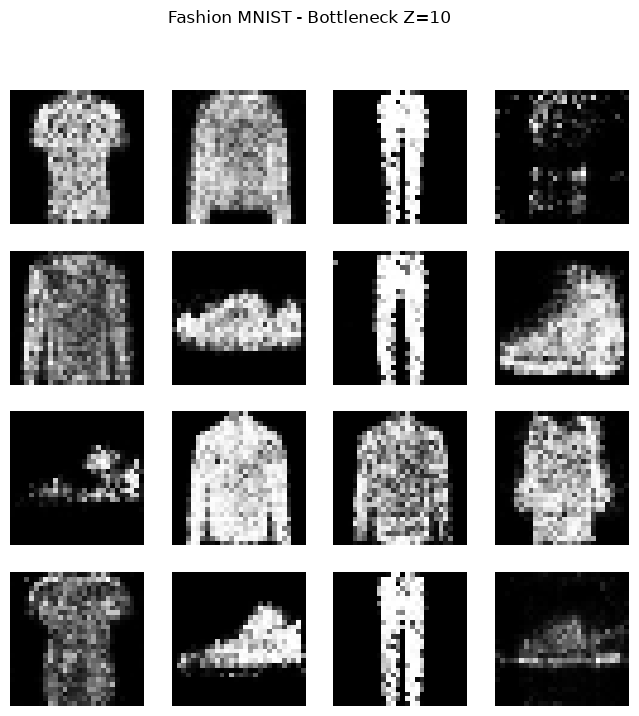

: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- 1. SETUP E IPERPARAMETRI (Risolve il NameError) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 10  # Compressione estrema
lr = 0.0002
batch_size = 64
epochs = 15

# Trasformazione per Fashion MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader = DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# --- 2. ARCHITETTURA ---
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() 
        )
    def forward(self, x):
        return self.main(x.view(-1, 784))

netG = Generator().to(device)
netD = Discriminator().to(device)
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# --- 3. TRAINING LOOP CON FEEDBACK ---
print(f"Avvio addestramento su {device} con Latent Dim: {latent_dim}")
print("-" * 60)

for epoch in range(epochs):
    running_loss_D = 0.0
    running_loss_G = 0.0
    d_x_eval = 0.0  # Media output D su reali
    d_gz_eval = 0.0 # Media output D su fake
    
    for i, (real_images, _) in enumerate(train_loader):
        b_size = real_images.size(0)
        real_images = real_images.to(device)

        # (A) UPDATE DISCRIMINATORE: massimizzare log(D(x)) + log(1 - D(G(z)))
        netD.zero_grad()
        
        # One-sided Label Smoothing: 0.9 per le immagini reali
        label_real = torch.full((b_size, 1), 0.9, device=device)
        output_real = netD(real_images)
        lossD_real = criterion(output_real, label_real)
        d_x_eval += output_real.mean().item()

        # Generazione fake
        noise = torch.randn(b_size, latent_dim, device=device)
        fake_images = netG(noise)
        label_fake = torch.zeros(b_size, 1, device=device)
        
        # Usiamo .detach() per non calcolare i gradienti di G
        output_fake = netD(fake_images.detach())
        lossD_fake = criterion(output_fake, label_fake)
        
        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # (B) UPDATE GENERATORE: massimizzare log(D(G(z)))
        netG.zero_grad()
        output_g = netD(fake_images) # Qui G "vuole" che D dica 0.9
        d_gz_eval += output_g.mean().item()
        
        lossG = criterion(output_g, label_real) 
        lossG.backward()
        optimizerG.step()
        
        running_loss_D += lossD.item()
        running_loss_G += lossG.item()

    # Statistiche epoca
    avg_D = running_loss_D / len(train_loader)
    avg_G = running_loss_G / len(train_loader)
    avg_dx = d_x_eval / len(train_loader)
    avg_dgz = d_gz_eval / len(train_loader)

    print(f"Epoca [{epoch+1}/{epochs}] | Loss_D: {avg_D:.3f} | Loss_G: {avg_G:.3f} | D(x): {avg_dx:.2f} | D(G(z)): {avg_dgz:.2f}")

print("-" * 60)

# --- 4. VISUALIZZAZIONE ---
with torch.no_grad():
    sample_noise = torch.randn(16, latent_dim, device=device)
    generated = netG(sample_noise).cpu()

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(generated[i][0], cmap='gray')
    plt.axis('off')
plt.suptitle(f"Fashion MNIST - Bottleneck Z={latent_dim}")
plt.show()